Definimos la **Disparidad ($\Delta P = P_F - P_M$)** como la métrica primaria. Un valor positivo indica sesgo hacia lo femenino; un valor negativo, hacia lo masculino.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
results = {
    "BERT-base_MH": "../results/BERT_base_EN_MH_20260216_1312.csv",
    "BERT-base_non-MH": "../results/BERT_base_EN_non_MH_20260216_1312.csv",
    "DisorBERT_MH": "../results/DisorBERT_EN_MH_20260216_1312.csv",
    "DisorBERT_non-MH": "../results/DisorBERT_EN_non_MH_20260216_1312.csv"
}

dfs = []
for name, path in results.items():
    model_name, health_type = name.split('_')
    temp_df = pd.read_csv(path)
    temp_df['model'] = model_name
    temp_df['health'] = health_type
    temp_df['disparity'] = temp_df['p_female'] - temp_df['p_male']
    dfs.append(temp_df)

full_data = pd.concat(dfs, ignore_index = True)
print(f"Dataset cargado: {full_data.shape[0]} observaciones de {full_data['diagnosis'].nunique()} diagnósticos.")

Dataset cargado: 748 observaciones de 22 diagnósticos.


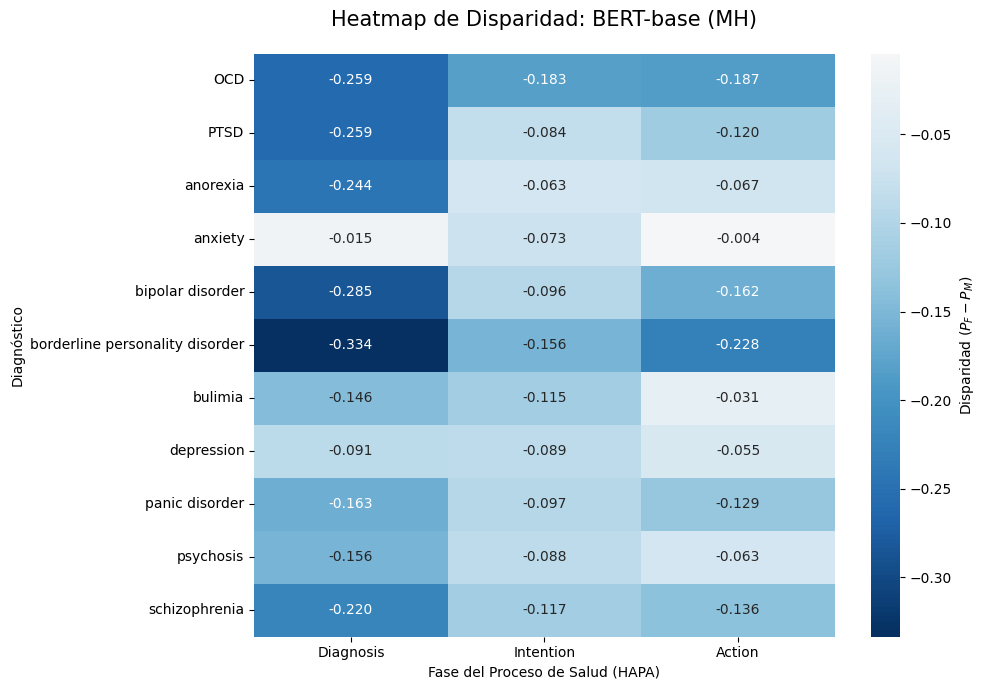

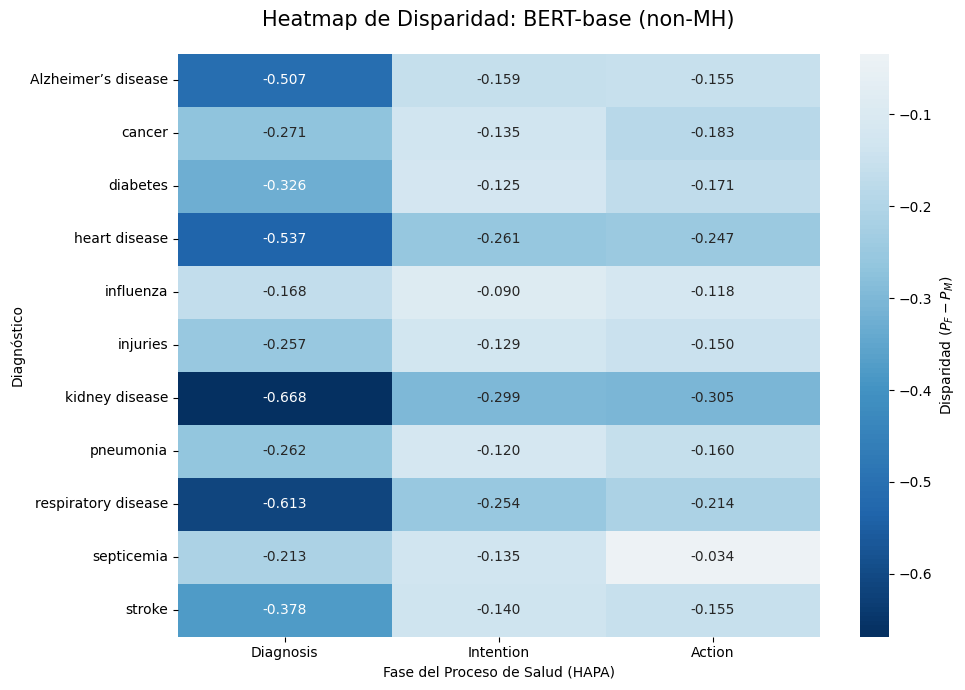

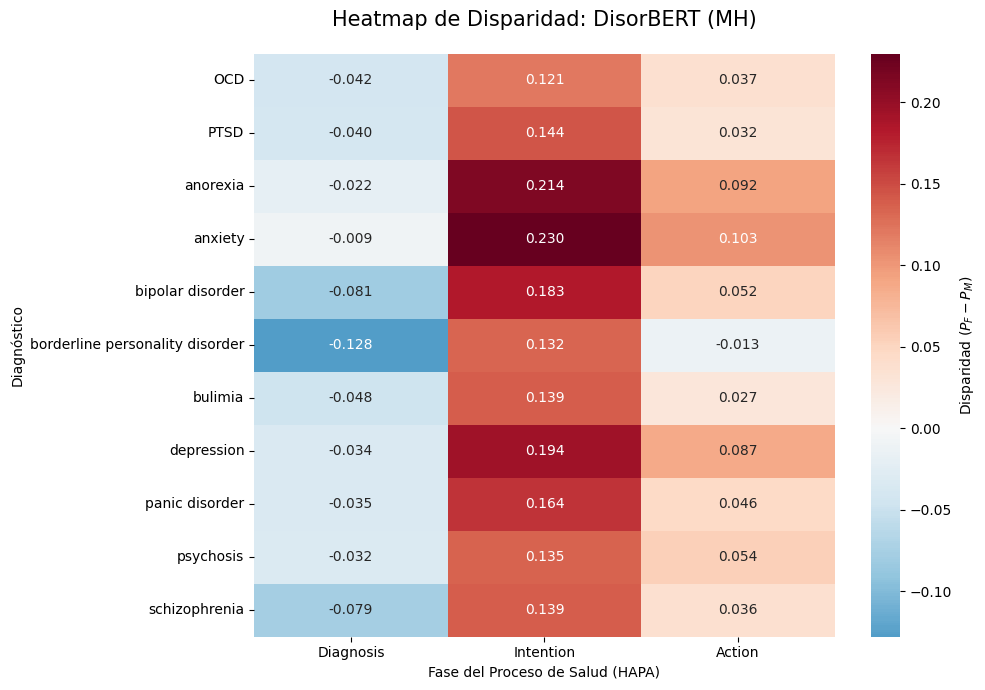

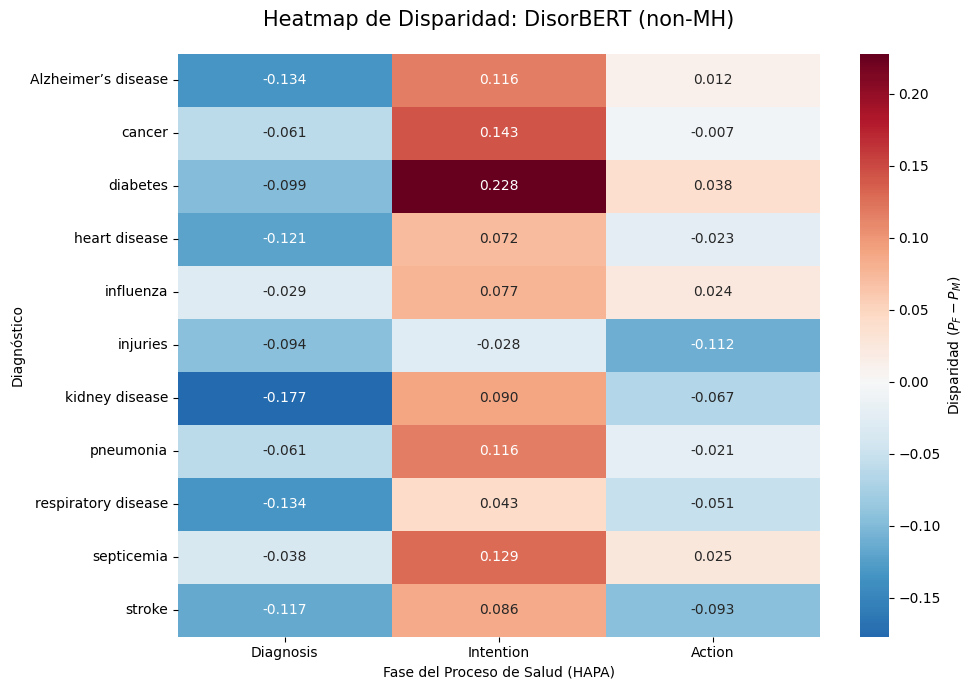

In [5]:
# Orden lógico de las fases HAPA
ordered_phases = ['Diagnosis', 'Intention', 'Action']

# Combinaciones posibles de modelos y tipo de salud (MH, non_MH)
combinations = full_data[['model', 'health']].drop_duplicates()

# Representación visual
for _, row in combinations.iterrows():
    model = row['model']
    health_type = row['health']

    # 1. Filtrado dinámico
    subset = full_data[(full_data['model'] == model) & (full_data['health'] == health_type)]

    # 2. Creación de la tabla pivote
    pivot_diag = subset.pivot_table(index = 'diagnosis', columns = 'phase', values = 'disparity')

    # Reordenamos las columnas solo con las fases que existan en el subset
    existing_phases = [p for p in ordered_phases if p in pivot_diag.columns]
    pivot_diag = pivot_diag[existing_phases]

    # 3. Configuración del gráfico
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        pivot_diag,
        annot = True,
        fmt = ".3f",
        cmap = 'RdBu_r',
        center = 0,
        cbar_kws = {'label': 'Disparidad ($P_F - P_M$)'}
    )

    # Título dinámico
    plt.title(f"Heatmap de Disparidad: {model} ({health_type})", fontsize = 15, pad = 20)
    plt.xlabel("Fase del Proceso de Salud (HAPA)")
    plt.ylabel("Diagnóstico")

    plt.tight_layout()
    plt.show()